# Statistical Time Series Forecasting — Notebook 1
## Introduction & Exploratory Data Analysis

**Goal:** Build *intuition* for what a time series is, what makes it different from cross-sectional data, and how to perform meaningful exploratory analysis on one.

---

### What is a time series?

A **time series** is a sequence of observations indexed in time order — typically equally spaced. Examples from business:

- Daily store sales  
- Monthly revenue or expenses  
- Hourly factory output  
- Weekly active users  
- Quarterly inventory levels  
...
The defining property: **the order matters.** Shuffling rows destroys information. That's why classical ML techniques like a random `train_test_split` are *wrong* here.

### The four classical components

| Component | Symbol | Description | Business example |
|-----------|--------|-------------|------------------|
| **Trend** | T(t) | Long-term direction | Year-on-year revenue growth |
| **Seasonality** | S(t) | Repeating pattern of fixed period | Sales spike every December |
| **Cyclic** | C(t) | Repeating pattern with no fixed period | Business cycles, fashion cycles |
| **Irregular / Residual** | ε(t) | Random noise, one-off events | Promo campaign, supply shock |

A time series can be modelled as:
- **Additive:** $y_t = T_t + S_t + \varepsilon_t$  (when seasonal swings are roughly constant in size)  
- **Multiplicative:** $y_t = T_t \times S_t \times \varepsilon_t$  (when seasonal swings grow with the level)


## Setup

Run this once per Colab session.

1. Upload `tsf_utils.py` to your Colab runtime (left sidebar → **Files** → upload), **or** mount Google Drive and add the folder to `sys.path`.
2. Place your dataset CSV/Excel file in the same location.
3. Run the cells below.


In [1]:
# Standard imports used throughout the tutorial
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from plotly.subplots import make_subplots

# In Colab, the notebook renderer is auto-detected. If plots don't show,
# uncomment the next line:
# pio.renderers.default = "colab"

pio.templates.default = "plotly_white"

# Our reusable utilities (returns plotly Figures)
import tsf_utils as tsf
print("tsf_utils loaded — sample functions:",
      [f for f in dir(tsf) if f.startswith('plot_')][:6], '...')


tsf_utils loaded — sample functions: ['plot_acf_pacf', 'plot_compare_pair', 'plot_distribution', 'plot_forecast', 'plot_intermittent_series', 'plot_lag'] ...


## 1. Loading your dataset

The helper `tsf.load_timeseries` handles the boring bits — parsing dates, sorting, reindexing to a fixed frequency, and filling missing values.

In [3]:
# ----------------------------------------------------------
# LOAD YOUR DATASET — edit these four lines for your data
# ----------------------------------------------------------
DATA_PATH   = "./us_retail_fred_dataset/us_retail.csv"   # path to CSV or .xlsx
DATE_COL    = "observation_date"               # column with timestamps
VALUE_COL   = "RSXFSN"              # column to forecast (univariate)
FREQ        = "MS"                 # 'D','W','MS','M','Q','A','H' or None

series = tsf.load_timeseries(
    path=DATA_PATH,
    date_col=DATE_COL,
    value_col=VALUE_COL,
    freq=FREQ,
    fill_method="interpolate",
)

print("Length:", len(series))
print("Frequency:", series.index.freqstr)
print("Range:", series.index.min(), "→", series.index.max())
series.head()


Length: 411
Frequency: MS
Range: 1992-01-01 00:00:00 → 2026-03-01 00:00:00


observation_date
1992-01-01    126717
1992-02-01    127022
1992-03-01    137978
1992-04-01    142314
1992-05-01    147550
Freq: MS, Name: RSXFSN, dtype: int64

## 2. The first plot

The single most important habit in time-series work: **plot it before you do anything else.** Try hovering, zooming, and panning the plot below.

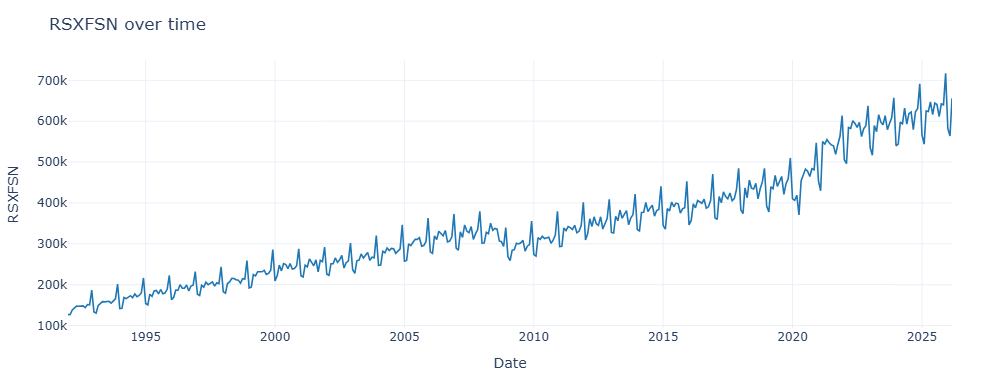

In [5]:
tsf.plot_timeseries(series, title=f"{VALUE_COL} over time", ylabel=VALUE_COL).show()

**What to look for in the plot:**

1. Is there a **trend**? (going up, down, flat?)
2. Is there **seasonality**? (regular ups and downs?)
3. Are the seasonal swings **constant** or **growing**? (additive vs multiplicative)
4. Are there **outliers** or **structural breaks** (sudden shifts)?
5. Is there visible **heteroskedasticity** (variance changing over time)?


## 3. Quick descriptive statistics

In [6]:
print("Summary statistics:")
print(series.describe().round(2))
print()
print("Missing values:", series.isna().sum())
print("Inferred seasonal period:", tsf.infer_seasonal_period(series))

Summary statistics:
count       411.00
mean     341204.47
std      135914.14
min      126717.00
25%      237330.00
50%      319640.00
75%      410004.50
max      716924.00
Name: RSXFSN, dtype: float64

Missing values: 0
Inferred seasonal period: 12


## 4. Distribution and outlier detection

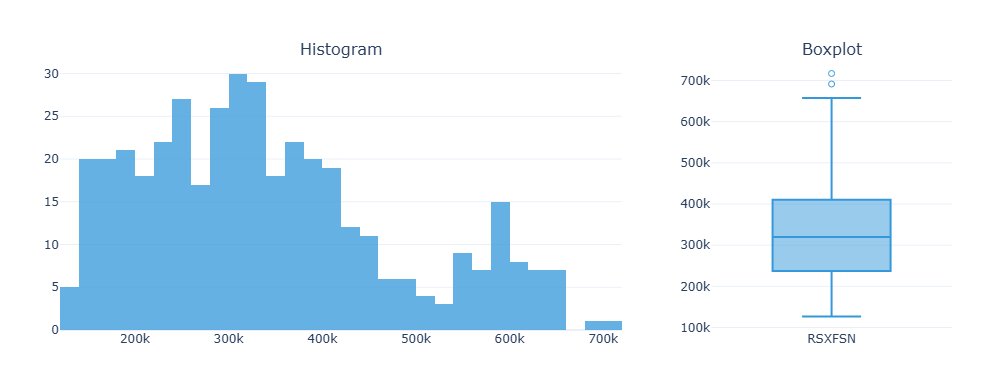

In [7]:
tsf.plot_distribution(series).show()

## 5. Rolling statistics — visual stationarity check

If the rolling mean drifts, or rolling std changes a lot, the series is likely **non-stationary** (we'll formalize this in Notebook 3). Toggle the legend entries to focus on one series at a time.

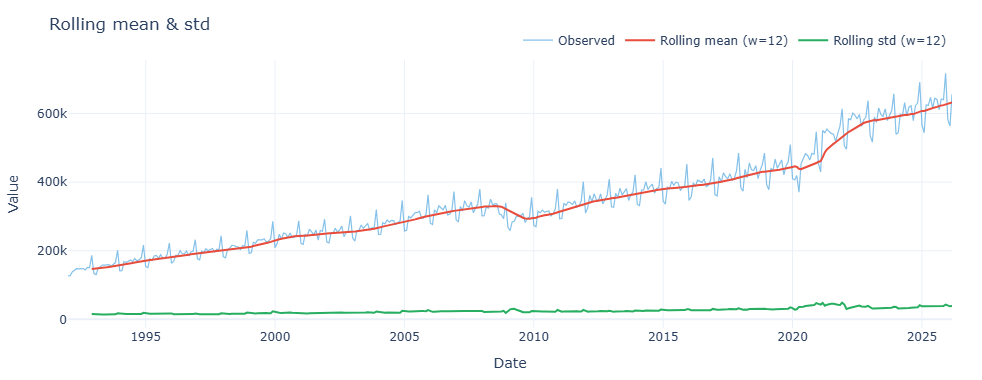

In [8]:
WINDOW = max(tsf.infer_seasonal_period(series), 12)
tsf.plot_rolling_statistics(series, window=WINDOW).show()

## 6. Seasonal view: one line per cycle

Plotting one seasonal cycle on top of the next makes seasonality jump out. Click a year in the legend to isolate it.

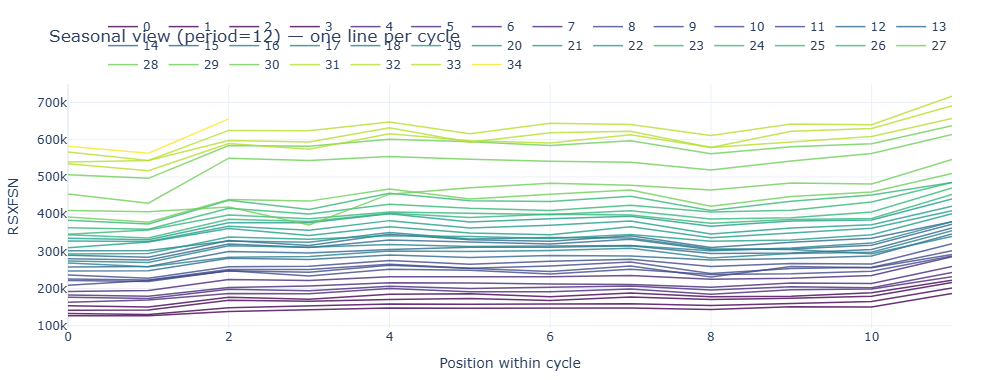

In [9]:
period = tsf.infer_seasonal_period(series)
if period > 1:
    tsf.plot_seasonal_view(series, period=period).show()
else:
    print("No clear seasonal frequency — skipping seasonal view.")

## 7. Lag plots: visual autocorrelation

If the points cluster along the diagonal, then `y(t)` is correlated with `y(t-k)` — a sign of memory in the process.

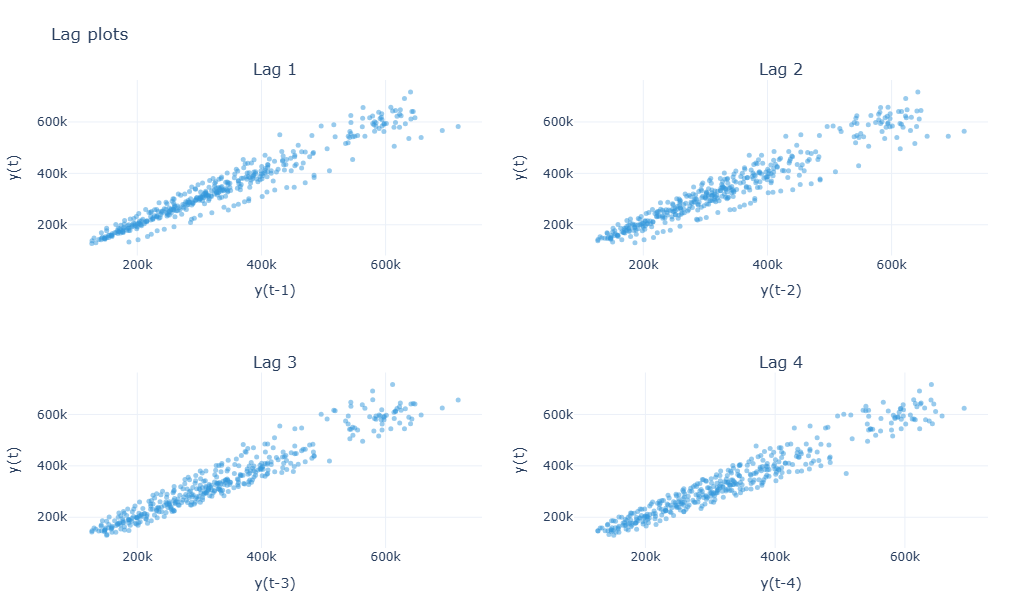

In [10]:
tsf.plot_lag(series, lags=(1, 2, 3, 4)).show()

## 8. Resampling: aggregating to a different frequency

Useful when your raw data is too noisy or too granular for the question you're asking.

In [11]:
# Examples — uncomment whichever applies
# monthly   = series.resample('M').sum()      # daily -> monthly totals
# weekly    = series.resample('W').mean()     # daily -> weekly averages
# quarterly = series.resample('Q').sum()      # monthly -> quarterly totals
# tsf.plot_timeseries(monthly, title='Monthly aggregate').show()

## Takeaways

- **Always plot first.** Most modelling decisions follow from what you see.
- **Identify trend, seasonality, and noise** visually before reaching for tests.
- **Check for missing values, outliers, and structural breaks** — they break models silently.
- **Use the interactive controls** to drill into particular date ranges or values during the session.

Next: **Notebook 2 — Time Series Decomposition**.
